# NB-2 · CervixViT — Novel Architecture & Training
**Paper**: *DualPathCervixNet: A Novel Hybrid CNN-Transformer with Cross-Attention Fusion for Cervical Cell Classification*  

### Novel Contributions in this Notebook
1. **DualPathCervixNet** — EfficientNet-B3 (local texture) + Swin-T (global morphology)  
2. **Cross-Attention Fusion Module (CAFM)** — bidirectional feature fusion  
3. **Class-Weighted Contrastive Focal Loss (CWCFL)** — handles cytology class imbalance  
4. Mixed precision training + gradient checkpointing for free Kaggle T4 GPU  

**Prerequisites**: Run NB-1 first — needs `train.csv`, `val.csv`, `class_weights.npy`

In [1]:
!pip install timm albumentations --quiet

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, cv2, random, warnings, time, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
class CFG:
    SEED        = 42
    IMG_SIZE    = 224
    BATCH_SIZE  = 32         # safe for T4 16GB with mixed precision
    NUM_CLASSES = 5
    EPOCHS      = 50
    PATIENCE    = 10         # early stopping

    # Optimiser
    LR          = 2e-4
    MIN_LR      = 1e-6
    WEIGHT_DECAY= 1e-4

    # CWCFL hyperparameters
    FOCAL_GAMMA      = 2.0
    LAMBDA_CONTRAST  = 0.3
    TEMPERATURE      = 0.07

    # CAFM
    FUSION_DIM  = 512
    NUM_HEADS   = 8
    DROPOUT     = 0.3

    DATA_DIR = Path('/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed')
    WORK_DIR = Path('/kaggle/working/')

    CLASS_NAMES = [
        'Dyskeratotic', 'Koilocytotic', 'Metaplastic',
        'Parabasal', 'Superficial_Intermediate'
    ]

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CFG.SEED)
print('Config ✓')

Config ✓


In [4]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────
def get_train_transforms(s):
    return A.Compose([
        A.Resize(s, s),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=20, border_mode=0, p=0.5),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5)),
            A.MedianBlur(blur_limit=3),
        ], p=0.3),
        A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
        A.CoarseDropout(max_holes=4, max_height=16, max_width=16, p=0.2),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])

def get_val_transforms(s):
    return A.Compose([
        A.Resize(s, s),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])


class CervixDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB)
        label = int(row['label'])
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label


df_train = pd.read_csv('/kaggle/input/notebooks/soumyaranjansahoo33/cervixvit-data-preprocessing-eda/train.csv')
df_val   = pd.read_csv('/kaggle/input/notebooks/soumyaranjansahoo33/cervixvit-data-preprocessing-eda/val.csv')

train_ds = CervixDataset(df_train, get_train_transforms(CFG.IMG_SIZE))
val_ds   = CervixDataset(df_val,   get_val_transforms(CFG.IMG_SIZE))

train_dl = DataLoader(train_ds, CFG.BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   CFG.BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

class_weights = torch.tensor(
    np.load('/kaggle/input/notebooks/soumyaranjansahoo33/cervixvit-data-preprocessing-eda/class_weights.npy'), dtype=torch.float32
).to(DEVICE)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Class weights: {class_weights.cpu().numpy().round(3)}')

Train: 2833 | Val: 608
Class weights: [0.995 0.982 1.02  1.028 0.975]


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# NOVEL COMPONENT 1: Cross-Attention Fusion Module (CAFM)
# ══════════════════════════════════════════════════════════════════════════════
class CrossAttentionFusionModule(nn.Module):
    """
    CAFM — Cross-Attention Fusion Module (Novel Contribution)
    
    Merges CNN local-texture features and ViT global-morphology features
    using bidirectional cross-attention:
      1) CNN attends to ViT  →  local queries enrich with global context
      2) ViT attends to CNN  →  global queries ground in local detail
    A learnable gate α blends the two enriched representations.
    A lightweight FFN + residual stabilises training.
    """
    def __init__(self, dim_cnn=1536, dim_vit=768, out_dim=512,
                 num_heads=8, dropout=0.1):
        super().__init__()
        self.out_dim = out_dim

        # Project both streams to the shared dimension
        self.proj_cnn = nn.Sequential(
            nn.Linear(dim_cnn, out_dim), nn.LayerNorm(out_dim), nn.GELU()
        )
        self.proj_vit = nn.Sequential(
            nn.Linear(dim_vit, out_dim), nn.LayerNorm(out_dim), nn.GELU()
        )

        # Bidirectional cross-attention
        self.attn_cnn2vit = nn.MultiheadAttention(
            out_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.attn_vit2cnn = nn.MultiheadAttention(
            out_dim, num_heads, dropout=dropout, batch_first=True
        )

        self.norm_c = nn.LayerNorm(out_dim)
        self.norm_v = nn.LayerNorm(out_dim)

        # Gated fusion + FFN
        self.gate = nn.Parameter(torch.tensor(0.5))
        self.ffn  = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim * 4), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim * 4, out_dim), nn.Dropout(dropout)
        )
        self.norm_out = nn.LayerNorm(out_dim)

    def forward(self, cnn_feat, vit_feat):
        # [B, D_cnn] → [B, 1, out_dim]
        q_c = self.proj_cnn(cnn_feat).unsqueeze(1)
        q_v = self.proj_vit(vit_feat).unsqueeze(1)

        # Bidirectional cross-attention
        c2v, _ = self.attn_cnn2vit(q_c, q_v, q_v)   # CNN queries ViT context
        v2c, _ = self.attn_vit2cnn(q_v, q_c, q_c)   # ViT queries CNN detail

        c_rich = self.norm_c(q_c + c2v).squeeze(1)   # [B, out_dim]
        v_rich = self.norm_v(q_v + v2c).squeeze(1)   # [B, out_dim]

        # Learnable gate blend
        g = torch.sigmoid(self.gate)
        merged = torch.cat([g * c_rich, (1 - g) * v_rich], dim=-1)  # [B, out_dim*2]

        # FFN with residual to mean of enriched paths
        fused = self.ffn(merged)
        fused = self.norm_out(fused + (c_rich + v_rich) / 2)
        return fused   # [B, out_dim]

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# NOVEL COMPONENT 2: Class-Weighted Contrastive Focal Loss (CWCFL)
# ══════════════════════════════════════════════════════════════════════════════
class CWCFL(nn.Module):
    """
    CWCFL — Class-Weighted Contrastive Focal Loss (Novel Contribution)
    
    L_total = L_focal + λ * L_contrast
    
    L_focal   : class-weighted focal loss to focus on hard, minority samples
    L_contrast: supervised NT-Xent contrastive loss on projected features
                pushes same-class cells together, different-class cells apart
                (critical for Koilocytotic vs Dyskeratotic confusion)
    """
    def __init__(self, num_classes=5, gamma=2.0,
                 lambda_c=0.3, temperature=0.07):
        super().__init__()
        self.gamma   = gamma
        self.lambda_c = lambda_c
        self.temp    = temperature

    def focal(self, logits, labels, weights):
        ce   = F.cross_entropy(logits, labels, weight=weights, reduction='none')
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

    def contrastive(self, features, labels):
        """
        Supervised contrastive loss.
        features: [B, D], L2-normalised
        """
        B = features.shape[0]
        f = F.normalize(features, dim=-1)
        sim = torch.matmul(f, f.T) / self.temp        # [B, B]

        lab  = labels.unsqueeze(1)
        pos_mask = (lab == lab.T).float()
        pos_mask.fill_diagonal_(0)
        neg_mask = 1 - torch.eye(B, device=features.device)

        exp_sim  = torch.exp(sim) * neg_mask
        pos_sum  = (exp_sim * pos_mask).sum(dim=-1)
        all_sum  = exp_sim.sum(dim=-1)

        loss    = -torch.log(pos_sum / (all_sum + 1e-8) + 1e-8)
        has_pos = (pos_mask.sum(dim=-1) > 0).float()
        return (loss * has_pos).sum() / (has_pos.sum() + 1e-8)

    def forward(self, logits, features, labels, weights):
        l_focal = self.focal(logits, labels, weights)
        l_cont  = self.contrastive(features, labels)
        total   = l_focal + self.lambda_c * l_cont
        return total, l_focal.item(), l_cont.item()

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# NOVEL ARCHITECTURE: DualPathCervixNet
# ══════════════════════════════════════════════════════════════════════════════
class DualPathCervixNet(nn.Module):
    """
    DualPathCervixNet — Novel Architecture (Central Contribution)
    
    Path A: EfficientNet-B3 pretrained backbone
            → extracts local nuclear texture features  [B, 1536]
    
    Path B: Swin Transformer Tiny (patch4 window7 224)
            → extracts global cell morphology features [B, 768]
    
    Fusion: CAFM (Cross-Attention Fusion Module)      [B, 512]
    
    Head:   Dropout → FC(512,256) → GELU → Dropout → FC(256,5)
    
    Projection head (for CWCFL contrastive training): FC(512,256) → GELU → FC(256,128)
    """
    def __init__(self, num_classes=5, fusion_dim=512, num_heads=8, dropout=0.3):
        super().__init__()

        # ── Path A: EfficientNet-B3 ────────────────────────────────────────
        self.cnn = timm.create_model(
            'efficientnet_b3', pretrained=True,
            num_classes=0, global_pool='avg'
        )
        cnn_dim = self.cnn.num_features   # 1536

        # ── Path B: Swin Transformer Tiny ─────────────────────────────────
        self.vit = timm.create_model(
            'swin_tiny_patch4_window7_224', pretrained=True,
            num_classes=0, global_pool='avg'
        )
        vit_dim = self.vit.num_features   # 768

        # ── CAFM Fusion ───────────────────────────────────────────────────
        self.cafm = CrossAttentionFusionModule(
            dim_cnn=cnn_dim, dim_vit=vit_dim,
            out_dim=fusion_dim, num_heads=num_heads
        )

        # ── Classification Head ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 256), nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )

        # ── Projection Head (contrastive loss only, not used at inference) ─
        self.proj = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.GELU(),
            nn.Linear(256, 128)
        )

    def forward(self, x, return_proj=False):
        cnn_feat = self.cnn(x)             # [B, 1536]
        vit_feat = self.vit(x)             # [B, 768]
        fused    = self.cafm(cnn_feat, vit_feat)  # [B, 512]
        logits   = self.classifier(fused)          # [B, 5]

        if return_proj:
            return logits, self.proj(fused)        # [B,5], [B,128]
        return logits


# Instantiate + quick forward pass
model = DualPathCervixNet(
    num_classes=CFG.NUM_CLASSES,
    fusion_dim=CFG.FUSION_DIM,
    num_heads=CFG.NUM_HEADS,
    dropout=CFG.DROPOUT
).to(DEVICE)

# Parameter count
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_p:,}')
print(f'Trainable params : {trainable_p:,}')

# Smoke test
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    logits, proj = model(dummy, return_proj=True)
    print(f'Forward pass OK  : logits {logits.shape} | proj {proj.shape}')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Total params     : 44,947,752
Trainable params : 44,947,752
Forward pass OK  : logits torch.Size([2, 5]) | proj torch.Size([2, 128])


In [8]:
# ── Optimiser & Scheduler ─────────────────────────────────────────────────────
#
# Differential learning rates:
#   - CNN backbone     : LR / 10   (already pretrained)
#   - ViT backbone     : LR / 10
#   - CAFM + head      : LR        (novel modules, train faster)
#
backbone_params = [
    {'params': model.cnn.parameters(), 'lr': CFG.LR / 10},
    {'params': model.vit.parameters(), 'lr': CFG.LR / 10},
]
head_params = [
    {'params': model.cafm.parameters(),       'lr': CFG.LR},
    {'params': model.classifier.parameters(), 'lr': CFG.LR},
    {'params': model.proj.parameters(),       'lr': CFG.LR},
]

optimizer = torch.optim.AdamW(
    backbone_params + head_params,
    weight_decay=CFG.WEIGHT_DECAY
)

# Cosine annealing with warm restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.EPOCHS, eta_min=CFG.MIN_LR
)

criterion = CWCFL(
    num_classes=CFG.NUM_CLASSES,
    gamma=CFG.FOCAL_GAMMA,
    lambda_c=CFG.LAMBDA_CONTRAST,
    temperature=CFG.TEMPERATURE
)

scaler = GradScaler()   # mixed precision
print('Optimiser, scheduler, loss ✓')

Optimiser, scheduler, loss ✓


In [9]:
# ── Training & Validation Functions ──────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, scaler, weights, device):
    model.train()
    losses, f_losses, c_losses, preds_all, labels_all = [], [], [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            logits, proj = model(imgs, return_proj=True)
            loss, lf, lc = criterion(logits, proj, labels, weights)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())
        f_losses.append(lf)
        c_losses.append(lc)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='macro')
    return np.mean(losses), np.mean(f_losses), np.mean(c_losses), acc, f1


@torch.no_grad()
def val_epoch(model, loader, criterion, weights, device):
    model.eval()
    losses, preds_all, labels_all = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast():
            logits, proj = model(imgs, return_proj=True)
            loss, _, _   = criterion(logits, proj, labels, weights)

        losses.append(loss.item())
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='macro')
    return np.mean(losses), acc, f1

print('Train / val functions defined ✓')

Train / val functions defined ✓


In [10]:
# ── Training Loop ─────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_focal': [], 'train_contrast': [],
    'train_acc':  [], 'train_f1':    [],
    'val_loss':   [], 'val_acc':     [], 'val_f1': [],
    'lr': []
}

best_val_f1    = 0.0
patience_count = 0
best_ckpt      = CFG.WORK_DIR / 'best_model.pth'

print(f'{'Epoch':>5}  {'TrLoss':>8}  {'TrAcc':>7}  {'TrF1':>7}  '
      f'{'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}  {'LR':>9}  {'Time':>6}')
print('-' * 80)

for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_fl, tr_cl, tr_acc, tr_f1 = train_epoch(
        model, train_dl, optimizer, criterion, scaler, class_weights, DEVICE
    )
    va_loss, va_acc, va_f1 = val_epoch(
        model, val_dl, criterion, class_weights, DEVICE
    )
    scheduler.step()
    lr_now = optimizer.param_groups[-1]['lr']

    # Log
    history['train_loss'].append(tr_loss)
    history['train_focal'].append(tr_fl)
    history['train_contrast'].append(tr_cl)
    history['train_acc'].append(tr_acc)
    history['train_f1'].append(tr_f1)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['val_f1'].append(va_f1)
    history['lr'].append(lr_now)

    elapsed = time.time() - t0
    mark = ' ← best' if va_f1 > best_val_f1 else ''
    print(f'{epoch:5d}  {tr_loss:8.4f}  {tr_acc:7.4f}  {tr_f1:7.4f}  '
          f'{va_loss:8.4f}  {va_acc:7.4f}  {va_f1:7.4f}  {lr_now:9.2e}  '
          f'{elapsed:5.1f}s{mark}')

    # Save best
    if va_f1 > best_val_f1:
        best_val_f1    = va_f1
        patience_count = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_f1':      va_f1,
            'val_acc':     va_acc,
            'history':     history,
            'cfg': {
                'num_classes': CFG.NUM_CLASSES,
                'fusion_dim':  CFG.FUSION_DIM,
                'num_heads':   CFG.NUM_HEADS,
                'dropout':     CFG.DROPOUT,
            }
        }, best_ckpt)
    else:
        patience_count += 1
        if patience_count >= CFG.PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (patience={CFG.PATIENCE})')
            break

print(f'\nTraining complete. Best Val F1 = {best_val_f1:.4f}')
print(f'Checkpoint saved → {best_ckpt}')

Epoch    TrLoss    TrAcc     TrF1    VaLoss    VaAcc     VaF1         LR    Time
--------------------------------------------------------------------------------
    1    0.3386   0.8457   0.8455    0.1817   0.9112   0.9120   2.00e-04   62.4s ← best
    2    0.1386   0.9329   0.9329    0.1590   0.9309   0.9305   1.99e-04   35.0s ← best
    3    0.1042   0.9460   0.9459    0.1471   0.9457   0.9461   1.98e-04   37.3s ← best
    4    0.0744   0.9640   0.9640    0.1371   0.9523   0.9527   1.97e-04   36.4s ← best
    5    0.0669   0.9679   0.9679    0.1335   0.9605   0.9606   1.95e-04   36.5s ← best
    6    0.0496   0.9746   0.9747    0.1182   0.9589   0.9591   1.93e-04   36.6s
    7    0.0444   0.9820   0.9820    0.1205   0.9622   0.9622   1.91e-04   36.5s ← best
    8    0.0444   0.9834   0.9834    0.0730   0.9622   0.9625   1.88e-04   36.3s ← best
    9    0.0392   0.9838   0.9838    0.1047   0.9704   0.9706   1.85e-04   36.3s ← best
   10    0.0320   0.9866   0.9866    0.1099   0.9688 

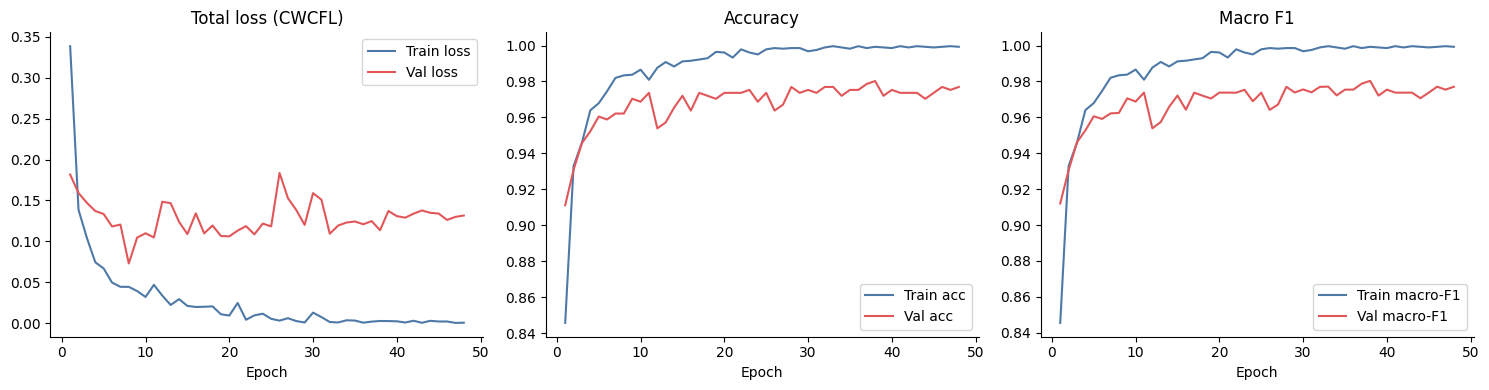

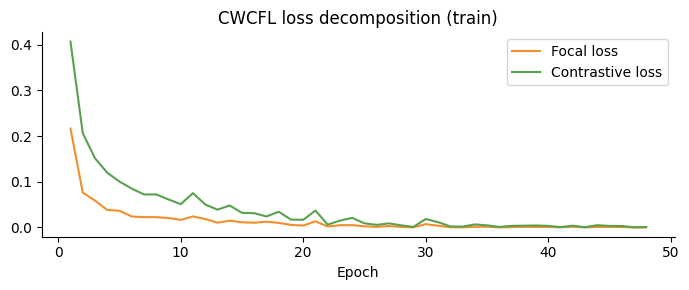

In [11]:
# ── Learning Curves ───────────────────────────────────────────────────────────
epochs_ran = len(history['train_loss'])
ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, history['train_loss'], label='Train loss', color='#4E79A7')
axes[0].plot(ep, history['val_loss'],   label='Val loss',   color='#E15759')
axes[0].set_title('Total loss (CWCFL)');   axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(ep, history['train_acc'], label='Train acc', color='#4E79A7')
axes[1].plot(ep, history['val_acc'],   label='Val acc',   color='#E15759')
axes[1].set_title('Accuracy');  axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[1].spines[['top','right']].set_visible(False)

axes[2].plot(ep, history['train_f1'], label='Train macro-F1', color='#4E79A7')
axes[2].plot(ep, history['val_f1'],   label='Val macro-F1',   color='#E15759')
axes[2].set_title('Macro F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG.WORK_DIR / 'learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()

# Loss decomposition
fig2, ax2 = plt.subplots(figsize=(7, 3))
ax2.plot(ep, history['train_focal'],    label='Focal loss',      color='#F28E2B')
ax2.plot(ep, history['train_contrast'], label='Contrastive loss', color='#59A14F')
ax2.set_title('CWCFL loss decomposition (train)'); ax2.legend(); ax2.set_xlabel('Epoch')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(CFG.WORK_DIR / 'loss_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()

In [12]:
# ── Save training history ─────────────────────────────────────────────────────
import json
with open(CFG.WORK_DIR / 'history.json', 'w') as f:
    json.dump(history, f)
print('history.json saved ✓')
print('\n✅ NB-2 Complete — proceed to NB-3 (Results & Analysis)')

history.json saved ✓

✅ NB-2 Complete — proceed to NB-3 (Results & Analysis)
